In [ ]:
!pip install torch torchvision numpy matplotlib Pillow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 837.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# Core neural network and tensor tools
import torch
import torch.nn as nn
import torch.nn.functional as F #for functions like loss functions,activation functions,Normalization functions etc
import torch.optim as optim

# For dataset loading and transformations
from torchvision import datasets, transforms

# For handling custom images and basic image I/O
from PIL import Image
import numpy as np

# Optional but very useful: visualization
import matplotlib.pyplot as plt

# For debugging image loading (optional)
import cv2 #for advance image processing

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#This code prepares the MNIST data so the neural network can easily and efficiently learn from it.

# Enhanced data augmentation for training data
train_transform = transforms.Compose([
    transforms.RandomRotation(15),                        # Random rotation between -15 to 15 degrees
    transforms.RandomAffine(0, translate=(0.1, 0.1)),     # Random shift up to 10% horizontally/vertically
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Random perspective transformation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Random brightness and contrast changes
     transforms.ToTensor(),                                # Convert to PyTorch tensor
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),   # Random erasing of rectangular patches

    transforms.Normalize((0.5,), (0.5,))                  # Normalize to [-1, 1]
])

# Test transform (no augmentation, just normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),    #this converts all pixel values between 0 and 1
    transforms.Normalize((0.5,), (0.5,))  #mean is 0.5 and S.D is 0.5 ,this converts all to values bw -1 to 1
])

#get training and testing images from mnist and do the above transformation
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

#Data loader: Organize photos into small groups
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.01MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.75MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.23MB/s]


In [ ]:
print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 60000
Testing dataset size: 10000


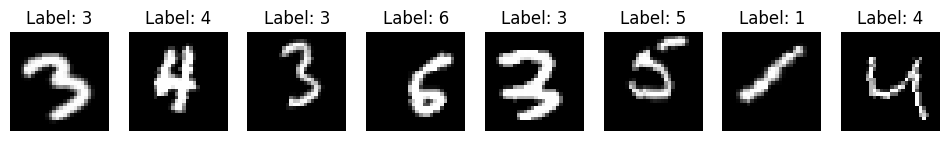

In [ ]:
# Get one batch of images and labels from the train_loader
data_iter = iter(train_loader)
images,labels = next(data_iter) #split them into pictures and their correct numbers


# Function to show images in a grid
def show_images(images, labels, n=8):
    plt.figure(figsize=(12, 3)) #12 inches wide and 3 inches tall
    for i in range(n):
        plt.subplot(1, n, i+1)
        # images[i] shape: [1, 28, 28], squeeze channel dimension for matplotlib
        img = images[i].squeeze().numpy() #convert to numpy from pytorch Tensor for matplotlib
        plt.imshow(img, cmap='gray')  #display the image in grayscale
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()

# Display 8 images and labels
show_images(images, labels, n=8)

In [ ]:
# def deskew(image):
#     """
#     Deskew the input image by estimating skew from image moments.
#     Applies correction only if skew is significant.
#     """
#     import cv2
#     import numpy as np

#     moments = cv2.moments(image)

#     # Prevent division by zero
#     if abs(moments['mu02']) < 1e-2:
#         return image.copy()

#     # Calculate skew
#     skew = moments['mu11'] / moments['mu02']

#     # Only apply deskew if skew is significant
#     if abs(skew) < 0.1:
#         return image.copy()

#     # Create affine transform to deskew
#     M = np.float32([[1, skew, -0.5 * skew * image.shape[0]], [0, 1, 0]])
#     deskewed = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR)

#     return deskewed


In [ ]:
def preprocess_custom_image_for_nn(image_path):
    """
    General preprocessing for all custom MNIST-style digit images.
    Works for both scanned (faint) and pen/digital images.
    """
    import cv2
    import numpy as np
    from PIL import Image
    import torchvision.transforms as transforms
    import os

    # Load image
    if isinstance(image_path, str):
        image = cv2.imread(image_path)
    else:
        image = image_path.copy()

    # Convert to grayscale
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert if background is white
    if np.mean(image) > 90:
        image = 255 - image

    # Apply CLAHE to enhance low contrast strokes
    # clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    # image = clahe.apply(image)

    # Threshold using Otsu  -- Converts grayscale to pure black and white
    image = cv2.GaussianBlur(image, (3, 3), 0) #---Smooths the image before thresholding
    # Detect shadow type
    shadow_variance = np.std(image)
    brightness_range = np.max(image) - np.min(image)

# Type 1: Blurry/faint images (shadow separate)
    if brightness_range < 100:  # Low contrast = blurry image
    # Use Otsu (works better for blurry images)
        _, image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Type 2: Sharp images with shadow overlap
    elif shadow_variance > 30:  # High variance = shadow mixed with digit
    # Use high threshold
        _, image = cv2.threshold(image, 180, 255, cv2.THRESH_BINARY)

# Type 3: Normal images
    else:
    # Use Otsu
        _, image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # shadow_variance = np.std(image)

    # if shadow_variance > 30:  # Shadow detected
    # # Use high threshold for shadow images
    #     _, image = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)
    # else:
    #     # Use Otsu or lower threshold for normal images
    #     _, image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Erode then dilate (morphological opening) to remove noise, enhance strokes
    # kernel = np.ones((1, 1), np.uint8)
    # image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel, iterations=1)
     # image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel, iterations=1)

    # Crop to digit using bounding box
    #finds the white pixels and draws a rectangle around it
    coords = cv2.findNonZero(image)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        # Add padding to prevent cutting off parts
        # padding = 6 # pixels
        # x = max(0, x - padding)
        # y = max(0, y - padding)
        # w = min(image.shape[1] - x, w + 2*padding)
        # h = min(image.shape[0] - y, h + 2*padding)
        image = image[y:y+h, x:x+w] #cuts out the digit from the image



    # Resize keeping aspect ratio
    #longest side exactly 25 pixels,other one changes proportionally
    h, w = image.shape
    if h > w:
        new_h, new_w = 25, int((w / h) * 25)
    else:
        new_w, new_h = 25, int((h / w) * 25)
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Take your resized digit and resize it to 28x28
    top = (28 - new_h) // 2
    bottom = 28 - new_h - top
    left = (28 - new_w) // 2
    right = 28 - new_w - left
    image = np.pad(image, ((top, bottom), (left, right)), mode='constant', constant_values=0)

    # Center the digit using image moments
    M = cv2.moments(image)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        shiftx = int(14 - cx)
        shifty = int(14 - cy)
        M_shift = np.float32([[1, 0, shiftx], [0, 1, shifty]])
        image = cv2.warpAffine(image, M_shift, (28, 28))




    # Convert to tensor and normalize
    image = Image.fromarray(image)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    return transform(image).unsqueeze(0)


In [ ]:
class CNNModel(nn.Module):
    def __init__(self): #building the components
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #Takes 1 grayscale image and creates 32 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)#Takes 32 feature maps and creates 64 feature maps
        #do we need more layers?
        self.pool = nn.MaxPool2d(2, 2)  #Keeps only the strongest signals and reduces the size to half
        self.dropout = nn.Dropout(0.25) #randomly turns 25 percent of feature map values to 0
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Output: 32x14x14
        x = self.pool(F.relu(self.conv2(x)))  # Output: 64x7x7
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)  #flatten to 1D,now its feature values not feature maps
        x = F.relu(self.fc1(x)) #from the 3136 feature values,it makes a new combo of 128 feature values
        x = self.fc2(x) #this makes a new combo of 10 feature values
        return x

# Initialize the model
model = CNNModel()
print(model)


CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


Using AdamW optimizer (direct import)
Scheduler created successfully
Epoch [1/12]
Train - Loss: 0.9046, Accuracy: 0.8602
Val   - Loss: 0.6046, Accuracy: 0.9846
LR: 0.000500
--------------------------------------------------


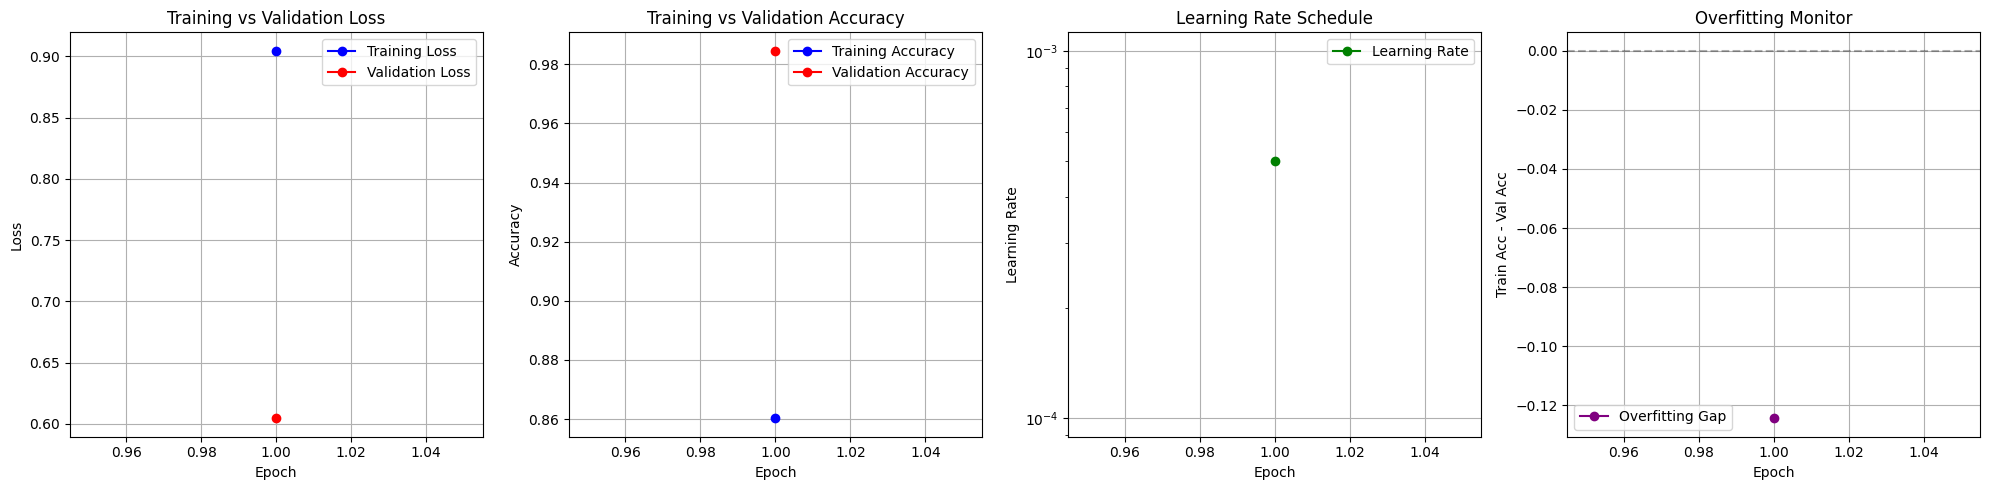

Epoch [2/12]
Train - Loss: 0.6655, Accuracy: 0.9564
Val   - Loss: 0.5659, Accuracy: 0.9907
LR: 0.000492
--------------------------------------------------


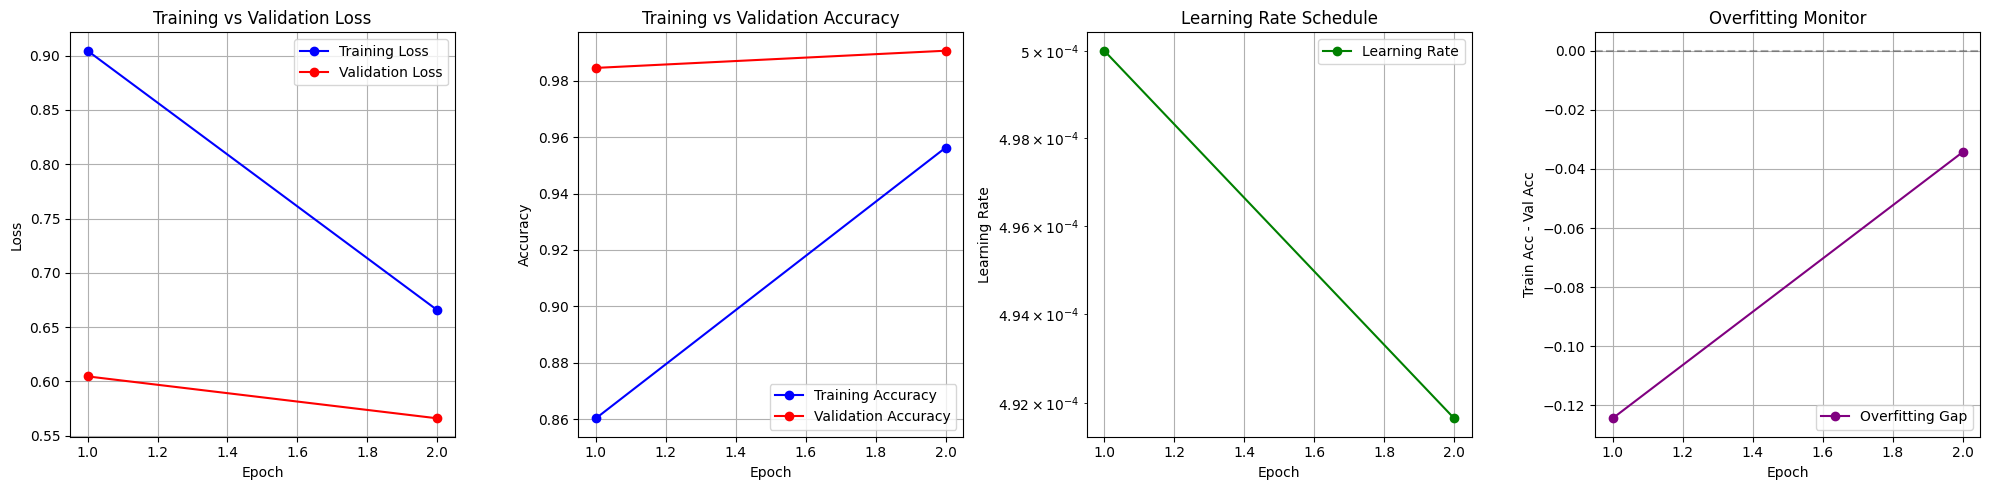

Epoch [3/12]
Train - Loss: 0.6324, Accuracy: 0.9651
Val   - Loss: 0.5610, Accuracy: 0.9923
LR: 0.000467
--------------------------------------------------


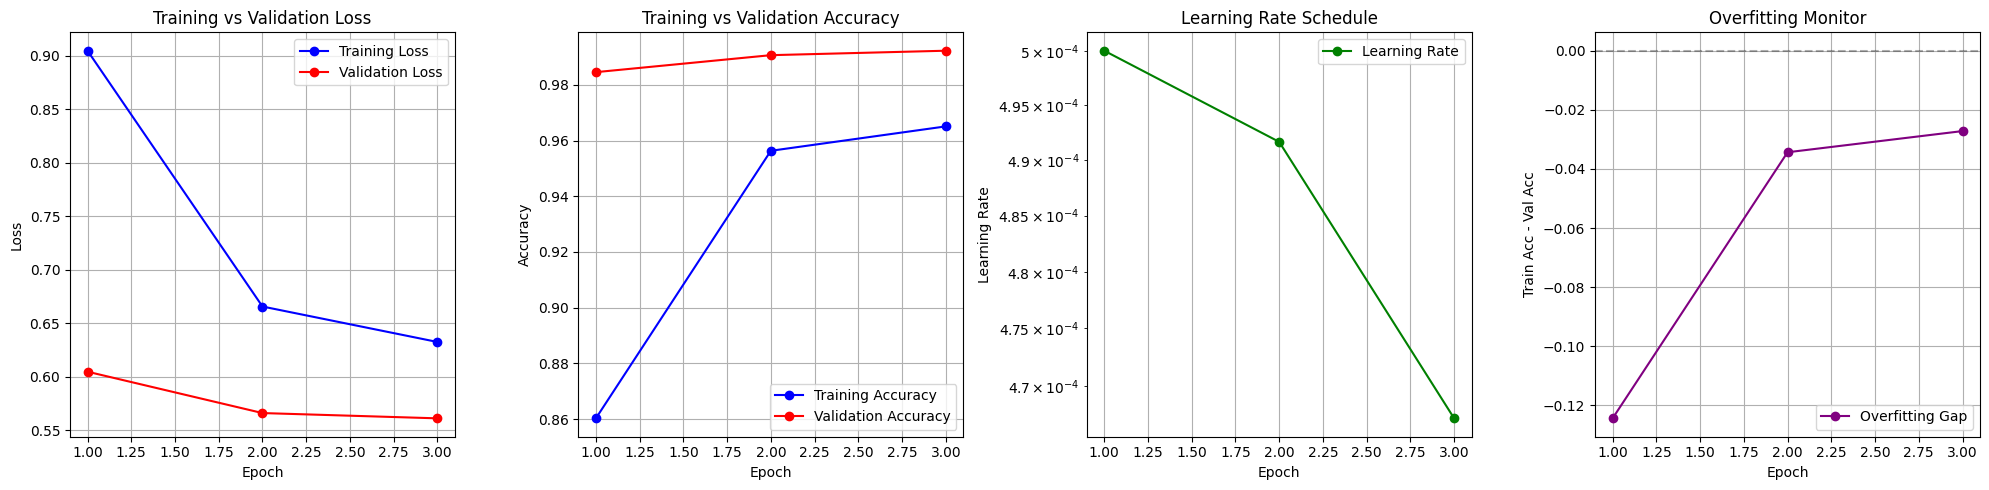

Epoch [4/12]
Train - Loss: 0.6178, Accuracy: 0.9698
Val   - Loss: 0.5500, Accuracy: 0.9932
LR: 0.000428
--------------------------------------------------


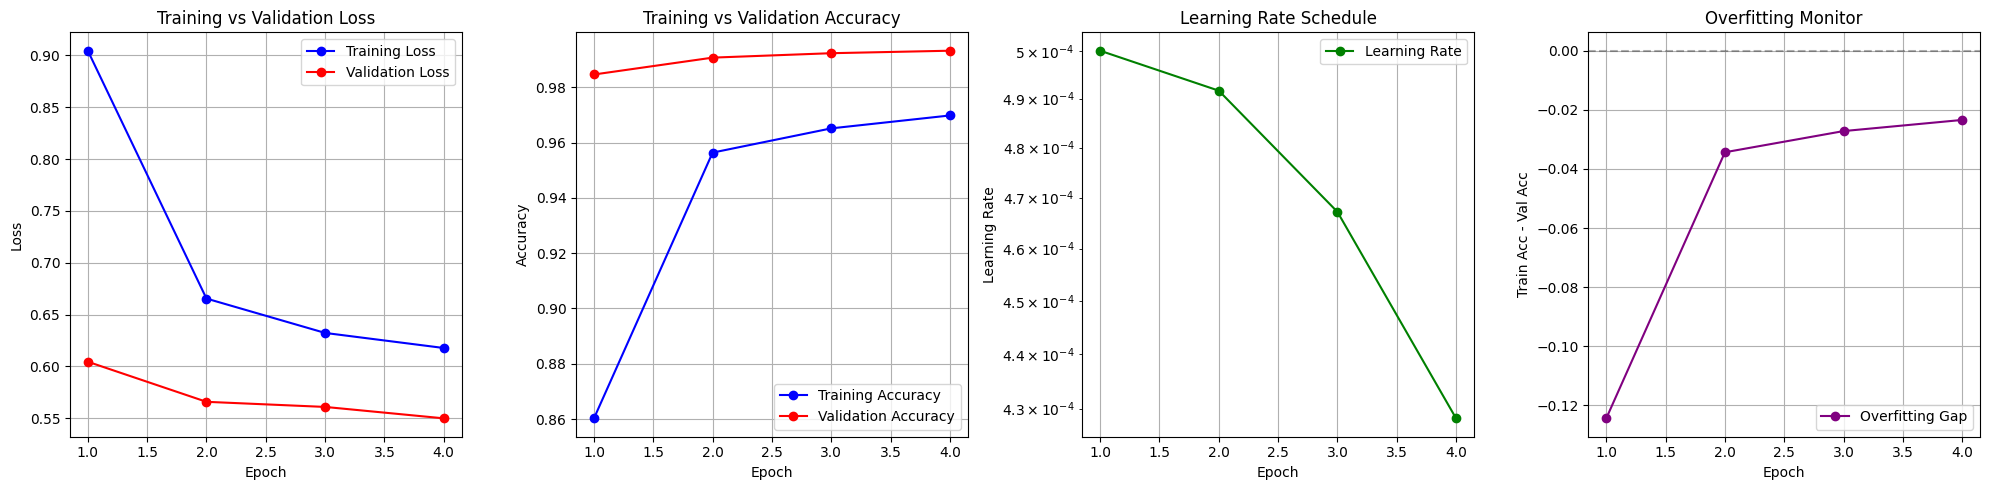

Epoch [5/12]
Train - Loss: 0.6073, Accuracy: 0.9722
Val   - Loss: 0.5453, Accuracy: 0.9936
LR: 0.000377
--------------------------------------------------


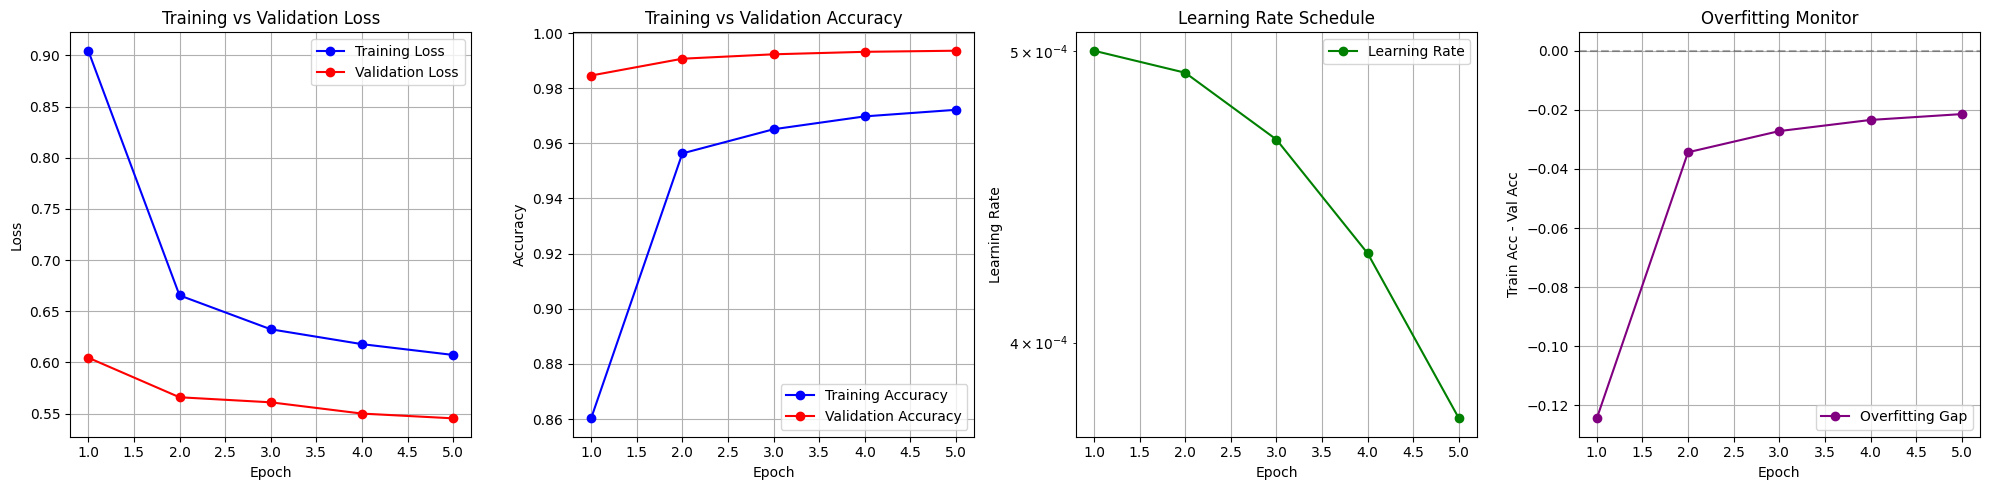

Epoch [6/12]
Train - Loss: 0.5993, Accuracy: 0.9746
Val   - Loss: 0.5431, Accuracy: 0.9935
LR: 0.000318
--------------------------------------------------


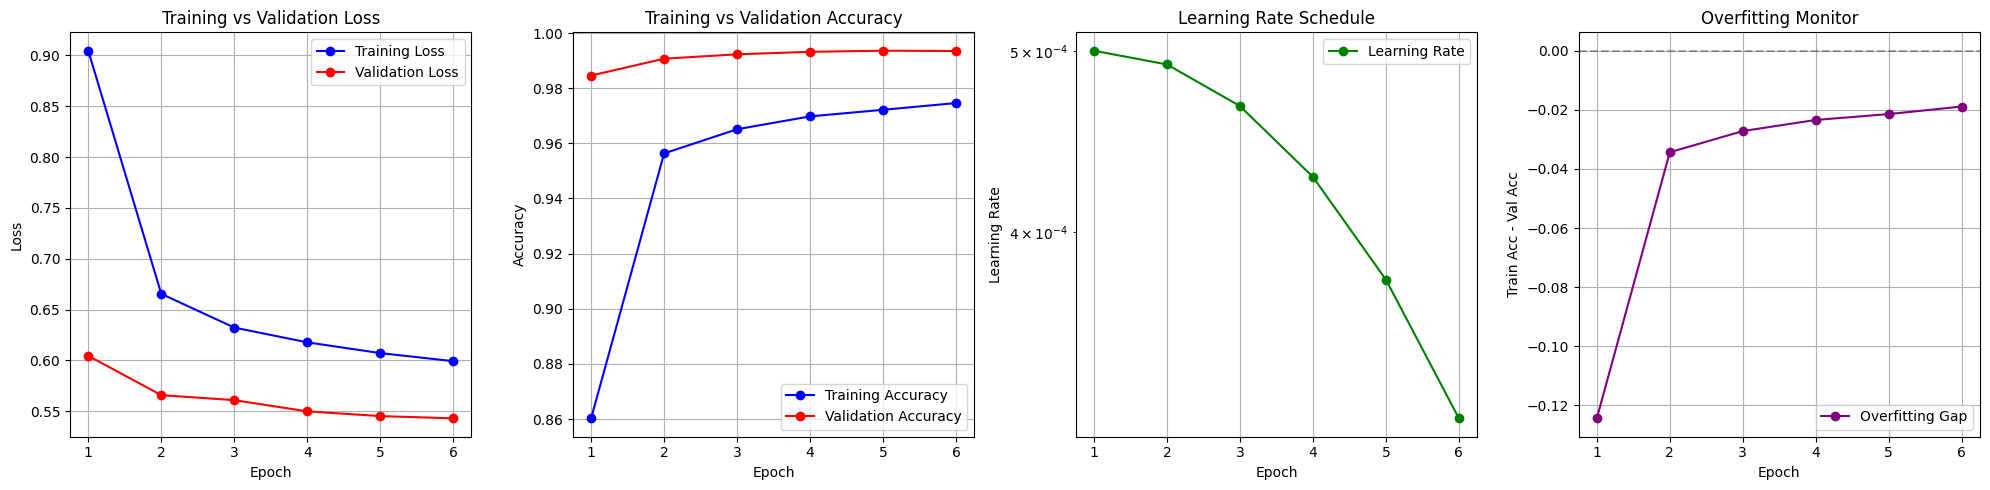

Epoch [7/12]
Train - Loss: 0.5938, Accuracy: 0.9761
Val   - Loss: 0.5383, Accuracy: 0.9949
LR: 0.000255
--------------------------------------------------


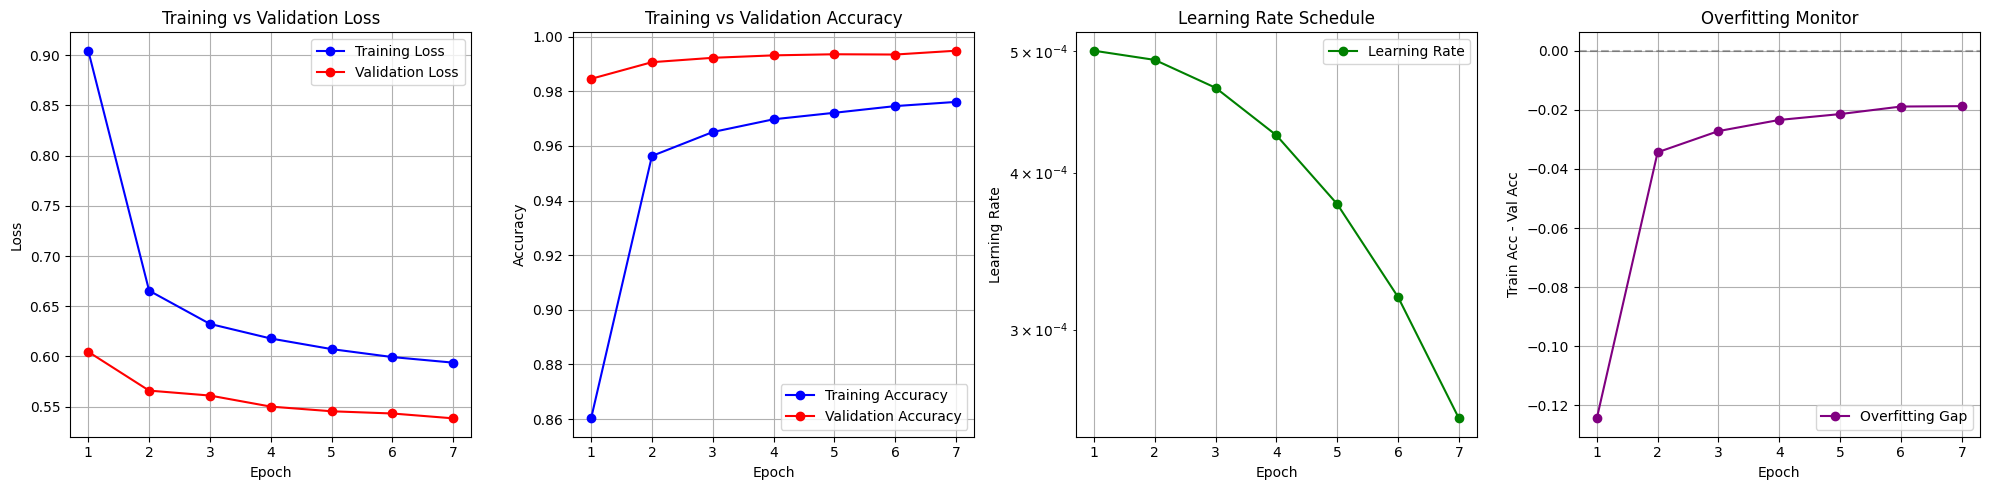

Epoch [8/12]
Train - Loss: 0.5892, Accuracy: 0.9779
Val   - Loss: 0.5371, Accuracy: 0.9947
LR: 0.000192
--------------------------------------------------


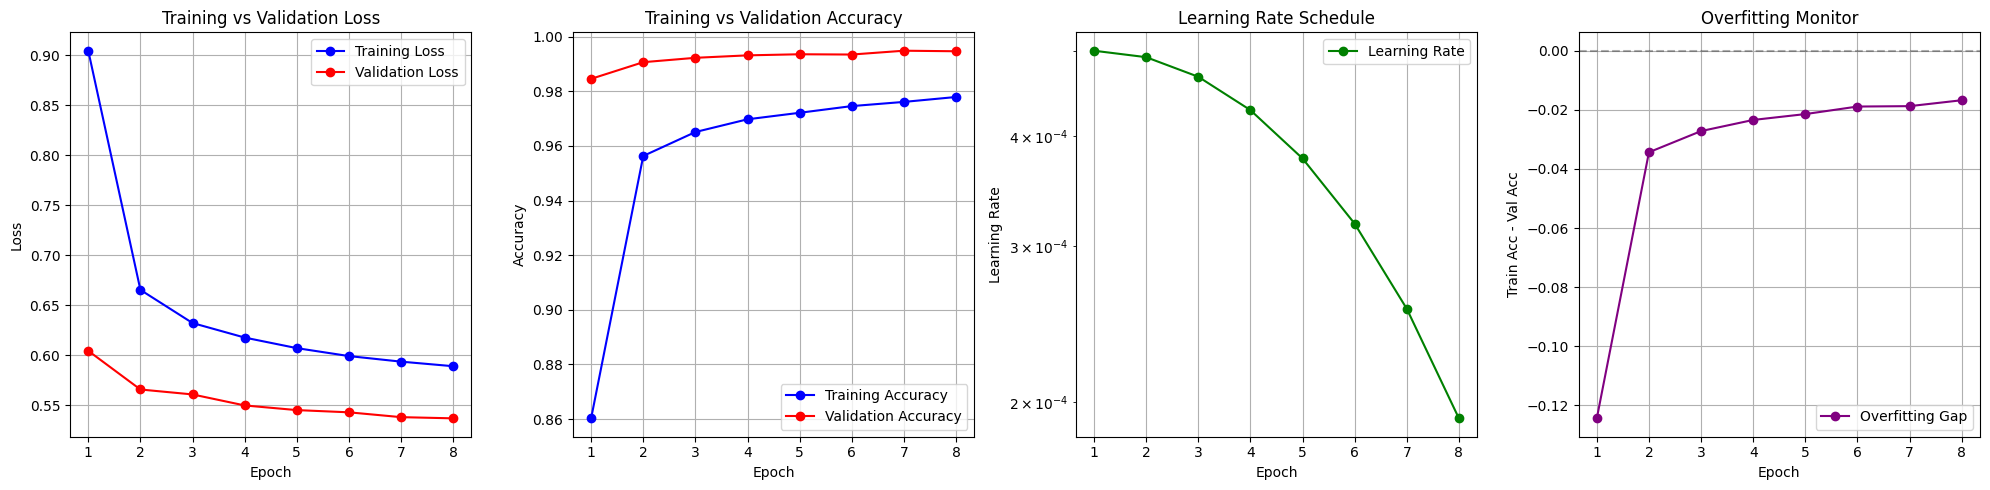

Epoch [9/12]
Train - Loss: 0.5853, Accuracy: 0.9789
Val   - Loss: 0.5354, Accuracy: 0.9942
LR: 0.000133
--------------------------------------------------


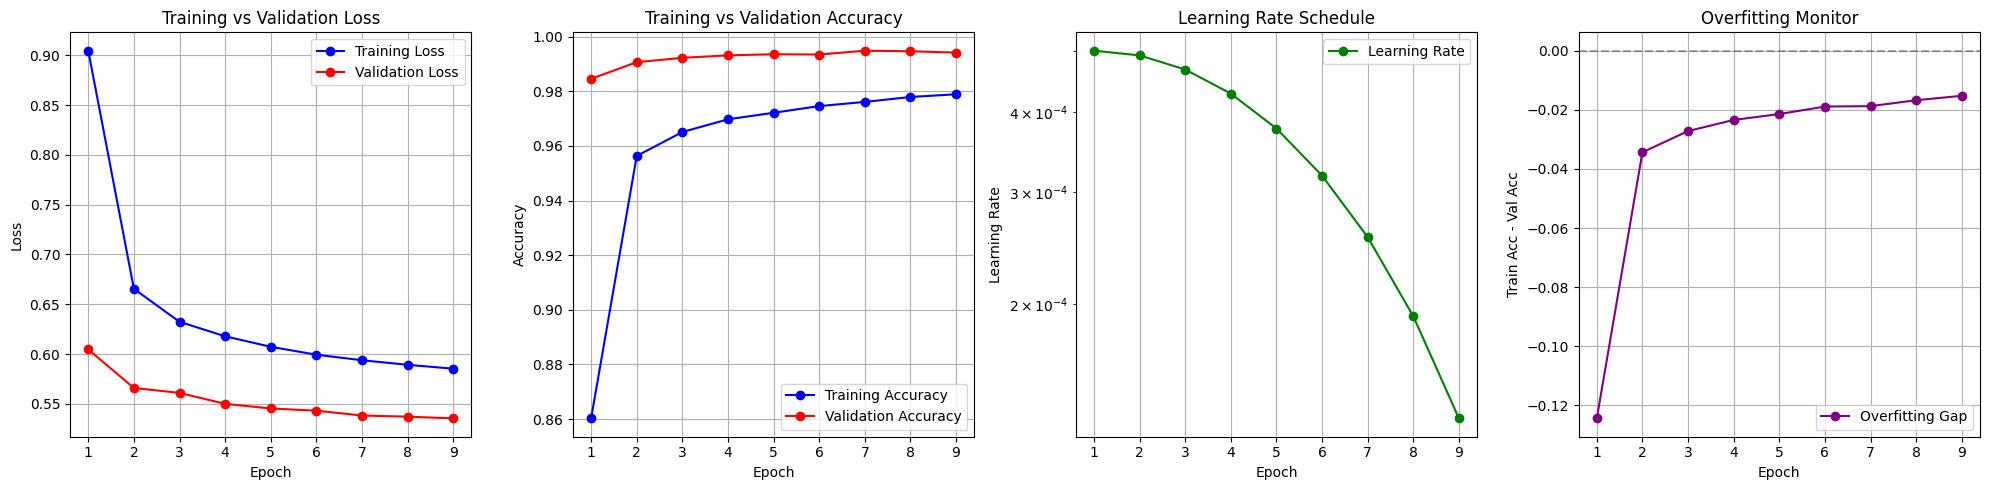

Epoch [10/12]
Train - Loss: 0.5827, Accuracy: 0.9790
Val   - Loss: 0.5348, Accuracy: 0.9950
LR: 0.000082
--------------------------------------------------


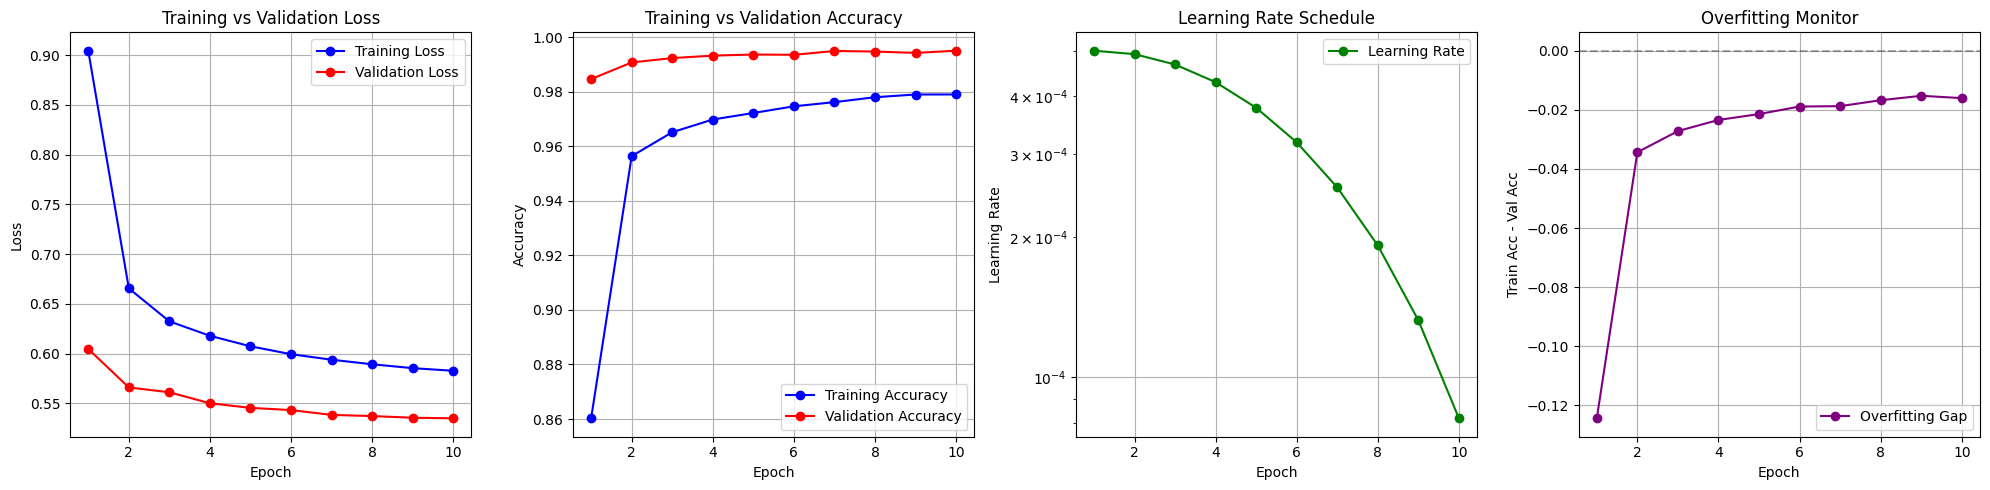

Epoch [11/12]
Train - Loss: 0.5792, Accuracy: 0.9804
Val   - Loss: 0.5335, Accuracy: 0.9950
LR: 0.000043
--------------------------------------------------


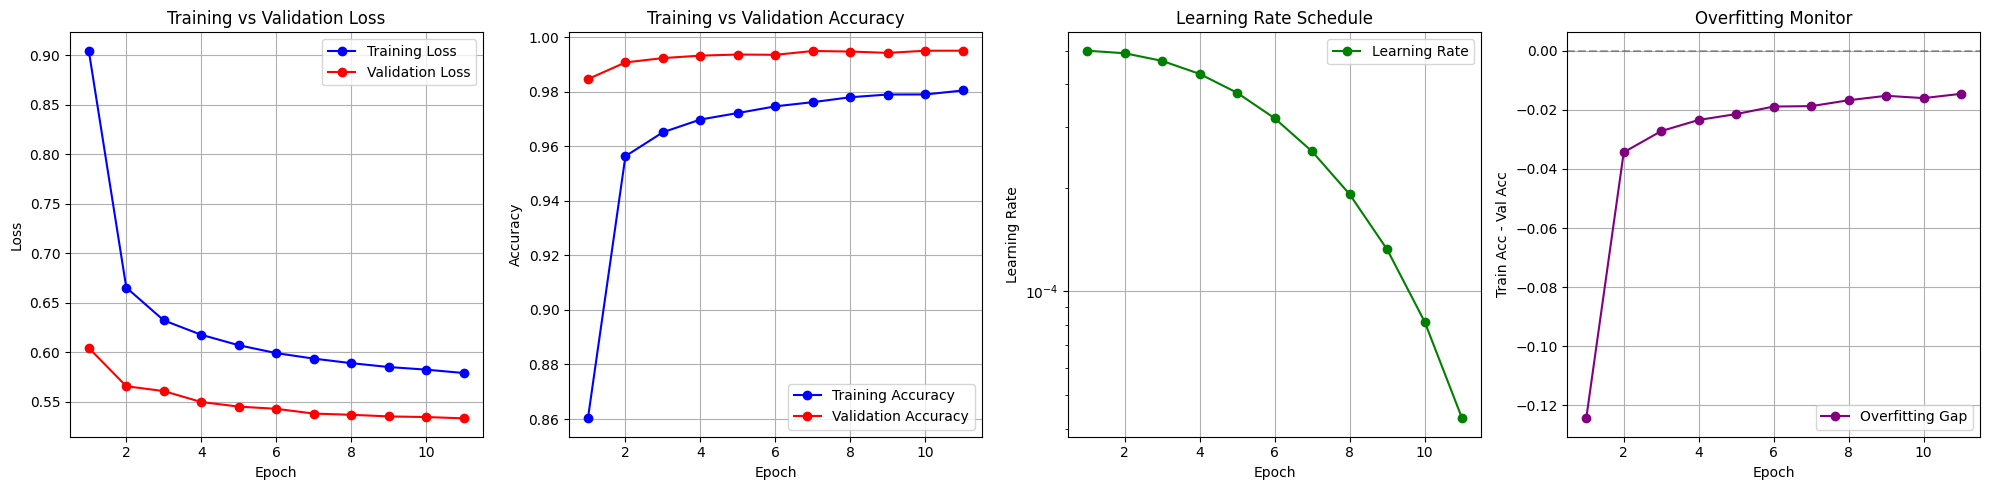

Epoch [12/12]
Train - Loss: 0.5793, Accuracy: 0.9807
Val   - Loss: 0.5329, Accuracy: 0.9957
LR: 0.000018
--------------------------------------------------


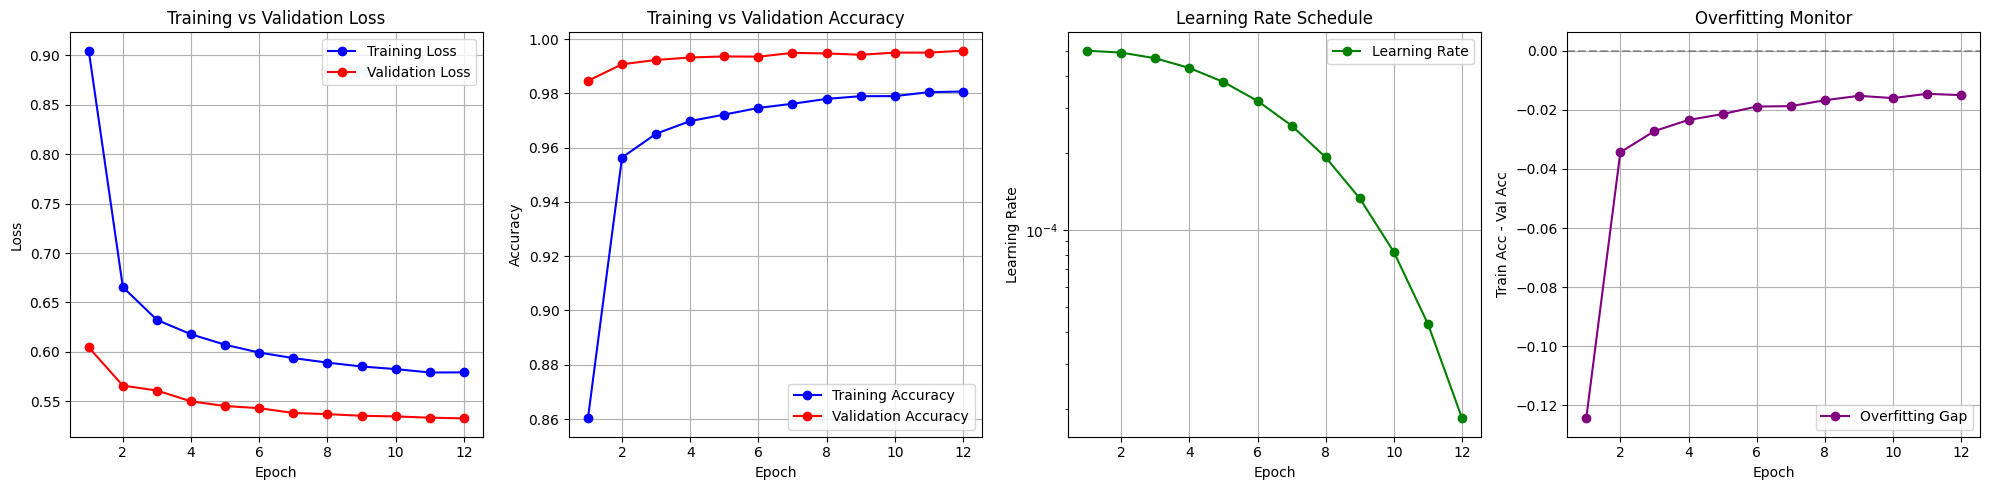

Loaded best model for final evaluation!


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
import sys

# Suppress warnings and disable dynamo compilation
warnings.filterwarnings('ignore')

# Critical fix: Disable torch compilation and dynamo to avoid circular import
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.disable = True

# Alternative approach: Completely bypass dynamo if possible
try:
    # Disable compilation features that might trigger dynamo
    torch.set_float32_matmul_precision('high')
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
except:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Use Label Smoothing for better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Better learning rate with weight decay - Fixed optimizer
initial_lr = 0.0005  # Slightly lower initial learning rate

# Nuclear option: Create optimizer by directly importing the class
def create_optimizer_nuclear(model, lr, weight_decay):
    """Create optimizer by directly importing optimizer classes"""
    try:
        # Try importing optimizers directly to bypass dynamo
        from torch.optim.adamw import AdamW
        optimizer = AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
            betas=(0.9, 0.999),
            eps=1e-08
        )
        print("Using AdamW optimizer (direct import)")
        return optimizer
    except Exception as e:
        print(f"Direct AdamW import failed: {e}")
        try:
            from torch.optim.adam import Adam
            optimizer = Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay,
                betas=(0.9, 0.999),
                eps=1e-08
            )
            print("Using Adam optimizer (direct import)")
            return optimizer
        except Exception as e2:
            print(f"Direct Adam import failed: {e2}")
            # Final fallback: SGD
            from torch.optim.sgd import SGD
            optimizer = SGD(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay,
                momentum=0.9
            )
            print("Using SGD optimizer (direct import)")
            return optimizer

# Try the nuclear option first
try:
    optimizer = create_optimizer_nuclear(model, initial_lr, 0.01)
except Exception as e:
    print(f"Nuclear option failed: {e}")
    # Absolute last resort: Manual parameter updates
    print("WARNING: Using manual parameter updates instead of optimizer!")

    # Create a simple manual optimizer
    class ManualOptimizer:
        def __init__(self, params, lr=0.001, weight_decay=0.0):
            self.params = list(params)
            self.lr = lr
            self.weight_decay = weight_decay
            self.param_groups = [{'lr': lr, 'weight_decay': weight_decay}]

        def zero_grad(self):
            for param in self.params:
                if param.grad is not None:
                    param.grad.zero_()

        def step(self):
            with torch.no_grad():
                for param in self.params:
                    if param.grad is not None:
                        # Apply weight decay
                        if self.weight_decay > 0:
                            param.data.mul_(1 - self.lr * self.weight_decay)
                        # Apply gradient update
                        param.data.add_(param.grad.data, alpha=-self.lr)

    optimizer = ManualOptimizer(model.parameters(), lr=initial_lr, weight_decay=0.01)
    print("Using manual optimizer implementation")

# Try to create scheduler
try:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12, eta_min=0.00001)
    print("Scheduler created successfully")
except Exception as e:
    print(f"Scheduler creation failed: {e}")
    # Manual scheduler
    class ManualScheduler:
        def __init__(self, optimizer, T_max, eta_min):
            self.optimizer = optimizer
            self.T_max = T_max
            self.eta_min = eta_min
            self.step_count = 0
            self.initial_lr = optimizer.param_groups[0]['lr']

        def step(self):
            import math
            self.step_count += 1
            lr = self.eta_min + (self.initial_lr - self.eta_min) * \
                 (1 + math.cos(math.pi * self.step_count / self.T_max)) / 2
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr

    scheduler = ManualScheduler(optimizer, T_max=12, eta_min=0.00001)
    print("Using manual scheduler implementation")

# Lists to store loss values
train_losses = []     #store loss values for each epoch
train_accuracies = [] #store acc values for each epoch
val_losses = []       #store validation loss values
val_accuracies = []   #store validation accuracy values
learning_rates = []   #store learning rate values for each epoch

# Early stopping parameters
best_val_loss = float('inf')
patience = 5
patience_counter = 0

# Training loop with validation
epochs = 12  # Increased epochs for better convergence
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate training metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_loader)
    val_epoch_accuracy = val_correct / val_total

    # Store values for plotting
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

    # Store current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Update learning rate
    scheduler.step()

    # Early stopping check
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
    print(f"Val   - Loss: {val_epoch_loss:.4f}, Accuracy: {val_epoch_accuracy:.4f}")
    print(f"LR: {current_lr:.6f}")
    print("-" * 50)

    # Clear previous plots and plot updated curves
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.plot(range(1, epoch+2), train_losses, 'b-o', label='Training Loss')
    plt.plot(range(1, epoch+2), val_losses, 'r-o', label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 4, 2)
    plt.plot(range(1, epoch+2), train_accuracies, 'b-o', label='Training Accuracy')
    plt.plot(range(1, epoch+2), val_accuracies, 'r-o', label='Validation Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 4, 3)
    plt.plot(range(1, epoch+2), learning_rates, 'g-o', label='Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')

    plt.subplot(1, 4, 4)
    plt.plot(range(1, epoch+2), [train_accuracies[i] - val_accuracies[i] for i in range(epoch+1)], 'purple', marker='o', label='Overfitting Gap')
    plt.title('Overfitting Monitor')
    plt.xlabel('Epoch')
    plt.ylabel('Train Acc - Val Acc')
    plt.legend()
    plt.grid(True)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping triggered! Best validation loss: {best_val_loss:.4f}")
        break

# Load best model for final evaluation
model.load_state_dict(torch.load('best_model.pth'))
print("Loaded best model for final evaluation!")

In [ ]:
# 5. Accuracy on test set
model.eval()
correct = 0
total = 0
with torch.no_grad(): #stop calculating gradients,just predict
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  #what position does Ai think is correct
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9957


In [ ]:
import os
from sklearn.metrics import accuracy_score

# Get all image files from folder
folder_path = "/content/drive/MyDrive/digits"  # Change this to your folder name
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

y_true, y_pred = [], []
model.eval()
with torch.no_grad():  # No gradient calculation needed for testing
   for fname in image_files:
       # Get the true label from filename
       true_label = int(fname.split('_')[0])
       y_true.append(true_label)

       # Preprocess for neural network
       tensor_image = preprocess_custom_image_for_nn(os.path.join(folder_path, fname))
       tensor_image = tensor_image.to(device)  # Move to same device as model

       # Make prediction
       output = model(tensor_image)
       _, predicted = torch.max(output, 1)
       pred = predicted.item()

       y_pred.append(pred)
       print(f"{fname}: true → {true_label}, predicted → {pred}")

acc = accuracy_score(y_true, y_pred)
print(f"\nCustom images accuracy: {acc * 100:.1f}%")

0_PS.jpeg: true → 0, predicted → 0
9_PS.jpeg: true → 9, predicted → 9
8_PS.jpeg: true → 8, predicted → 8
7_PS.jpeg: true → 7, predicted → 7
6_PS.jpeg: true → 6, predicted → 6
5_PS.jpeg: true → 5, predicted → 5
4_PS.jpeg: true → 4, predicted → 4
3_PS.jpeg: true → 3, predicted → 3
2_PS.jpeg: true → 2, predicted → 2
1_PS.jpeg: true → 1, predicted → 1
0_PS1.jpeg: true → 0, predicted → 0
9_PS1.jpeg: true → 9, predicted → 9
8_PS1.jpeg: true → 8, predicted → 8
7_PS1.jpeg: true → 7, predicted → 7
6_PS1.jpeg: true → 6, predicted → 6
5_PS1.jpeg: true → 5, predicted → 5
4_PS1.jpeg: true → 4, predicted → 4
3_PS1.jpeg: true → 3, predicted → 3
2_PS1.jpeg: true → 2, predicted → 2
1_PS1.jpeg: true → 1, predicted → 1
9_H1.jpeg: true → 9, predicted → 2
8_H.jpeg: true → 8, predicted → 3
7_H.jpeg: true → 7, predicted → 7
6_H.jpeg: true → 6, predicted → 6
5_H.jpeg: true → 5, predicted → 5
4_H.jpeg: true → 4, predicted → 4
0_H1.jpeg: true → 0, predicted → 0
1_H.jpeg: true → 1, predicted → 1
2_H.jpeg: true →

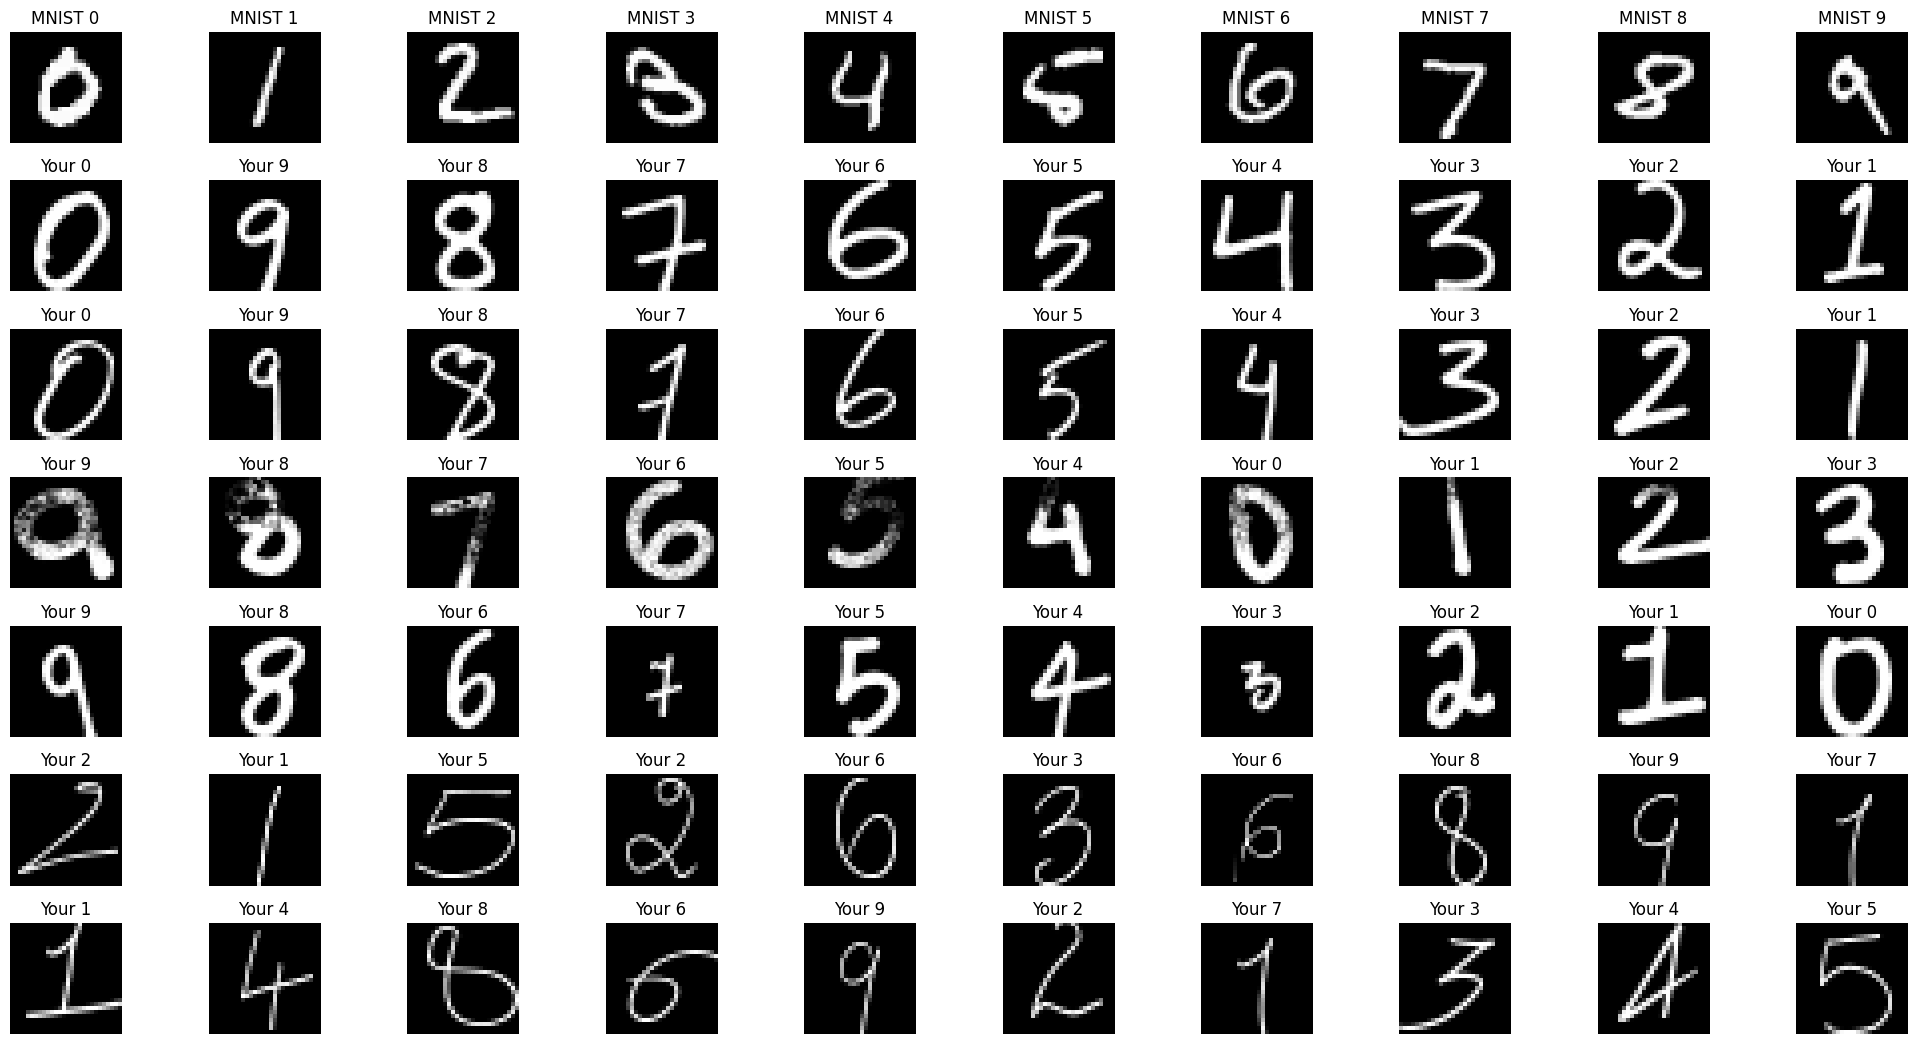

In [ ]:
plt.figure(figsize=(20,15)) # Adjusted figure size for more rows
target_digits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
examples = []      # Will store MNIST images
labels_list = []   # Will store their corresponding labels

for images, labels in test_loader:
   examples.extend(images)
   labels_list.extend(labels)
   if len(examples) >= 1000:  # Get enough examples
       break
# Find and display MNIST images
# MNIST images (top row - positions 1-10)
for i, digit in enumerate(target_digits):
   # Find first occurrence of this digit
   for j, label in enumerate(labels_list):
       if label.item() == digit:
           mnist_sample = examples[j].squeeze().numpy()  # Convert tensor to numpy
           break

   #print the whole thing in 2 rows and 10 columns


   plt.subplot(10, 10, i + 1)  # 10x10 grid, MNIST from 1 to 10
   plt.imshow(mnist_sample, cmap='gray')
   plt.title(f'MNIST {digit}')
   plt.axis('off')
# Show your processed digits
folder_path = "/content/drive/MyDrive/digits"  # Change this to your folder name
your_digits = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
for i, fname in enumerate(your_digits[:60]):
   plt.subplot(10, 10, i + 11)  # Starts from position 11 (after 10 MNIST digits)
   # Convert tensor back to numpy for visualization
   tensor_img = preprocess_custom_image_for_nn(os.path.join(folder_path, fname))
   processed = tensor_img.squeeze().numpy()  # Remove batch and channel dims
   plt.imshow(processed, cmap='gray')
   plt.title(f'Your {fname[0]}')
   plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
